# Existing RPKM plotting scripts transferred to a notebook

The four sections below preserve the structure of the existing `.py` scripts. Only input/output paths, requested colors, and grid lines differ.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path('/cta/users/guneyn23/rpkm')
COLORS = {
    'ATAC': '#d62828',
    'H3K9me3': '#003049',
    'H3K27me3': '#f77f00',
}

DATASETS = {
    '64': {
        'atac_file': BASE_DIR / '64_rpkm/ATAC_mean_normalized_rpkm.tsv',
        'h3k9me3_file': BASE_DIR / '64_rpkm/H3K9me3_mean_normalized_rpkm.tsv',
        'h3k27me3_file': BASE_DIR / '64_rpkm/H3K27me3_mean_normalized_rpkm.tsv',
        'output_dir': BASE_DIR / 'rpkm_plots/64 plots',
        'title_name': '6-4PP',
    },
    'CPD': {
        'atac_file': BASE_DIR / 'CPD_rpkm/atac_rpkm/mean_rpkm_ratio.tsv',
        'h3k9me3_file': BASE_DIR / 'CPD_rpkm/close_rpkm/H3K9me3_mean_rpkm_ratio.tsv',
        'h3k27me3_file': BASE_DIR / 'CPD_rpkm/close_rpkm/H3K27me3_mean_rpkm_ratio.tsv',
        'output_dir': BASE_DIR / 'rpkm_plots/CPD plots',
        'title_name': 'CPD',
    },
}

## 1. Normal real/sim RPKM ratio — from `plot_combined_ratio.py`

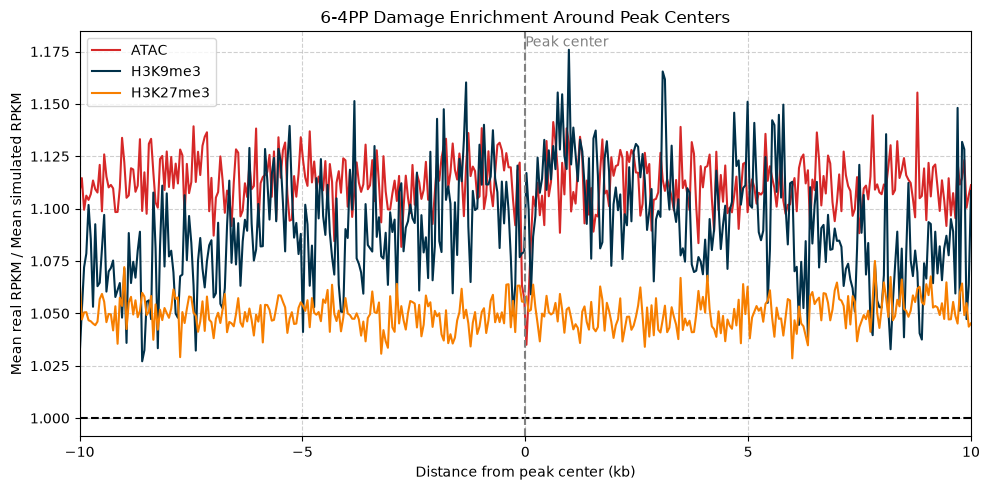

Combined line plot written to: /cta/users/guneyn23/rpkm/rpkm_plots/64 plots/64_real_sim_ratio.png


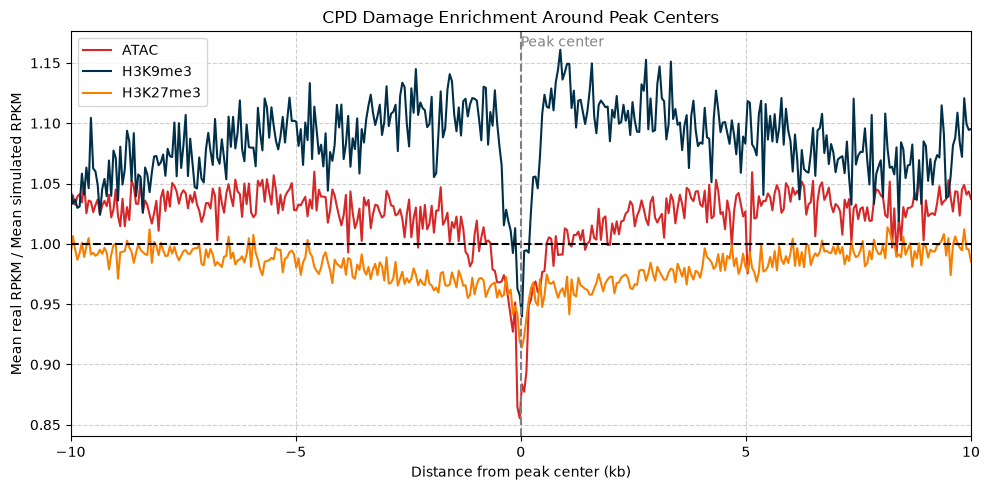

Combined line plot written to: /cta/users/guneyn23/rpkm/rpkm_plots/CPD plots/CPD_real_sim_ratio.png


In [2]:
for dataset_name, files in DATASETS.items():
    atac_file = files['atac_file']
    h3k9me3_file = files['h3k9me3_file']
    h3k27me3_file = files['h3k27me3_file']
    plot_file = files['output_dir'] / f'{dataset_name}_real_sim_ratio.png'
    files['output_dir'].mkdir(parents=True, exist_ok=True)

    atac = pd.read_csv(atac_file, sep='\t')
    h3k9me3 = pd.read_csv(h3k9me3_file, sep='\t')
    h3k27me3 = pd.read_csv(h3k27me3_file, sep='\t')

    x_atac = np.linspace(-10, 10, len(atac))
    x_h3k9me3 = np.linspace(-10, 10, len(h3k9me3))
    x_h3k27me3 = np.linspace(-10, 10, len(h3k27me3))

    plt.figure(figsize=(10, 5))
    plt.plot(x_atac, atac['real_sim_ratio'], color=COLORS['ATAC'], label='ATAC')
    plt.plot(x_h3k9me3, h3k9me3['real_sim_ratio'], color=COLORS['H3K9me3'], label='H3K9me3')
    plt.plot(x_h3k27me3, h3k27me3['real_sim_ratio'], color=COLORS['H3K27me3'], label='H3K27me3')

    plt.xlabel('Distance from peak center (kb)')
    plt.ylabel('Mean real RPKM / Mean simulated RPKM')
    plt.title(f"{files['title_name']} Damage Enrichment Around Peak Centers")
    plt.axhline(y=1, color='black', linestyle='--')
    plt.axvline(x=0, color='gray', linestyle='--')
    plt.text(0, max(atac['real_sim_ratio'].max(), h3k9me3['real_sim_ratio'].max(), h3k27me3['real_sim_ratio'].max()), 'Peak center', color='gray', ha='left', va='bottom')
    plt.xlim(-10, 10)
    plt.xticks([-10, -5, 0, 5, 10])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_file, dpi=300)
    plt.show()
    plt.close()
    print(f'Combined line plot written to: {plot_file}')

## 2. 6–10 kb baseline-normalized real/sim ratio — from `fold_baseline_plot.py`

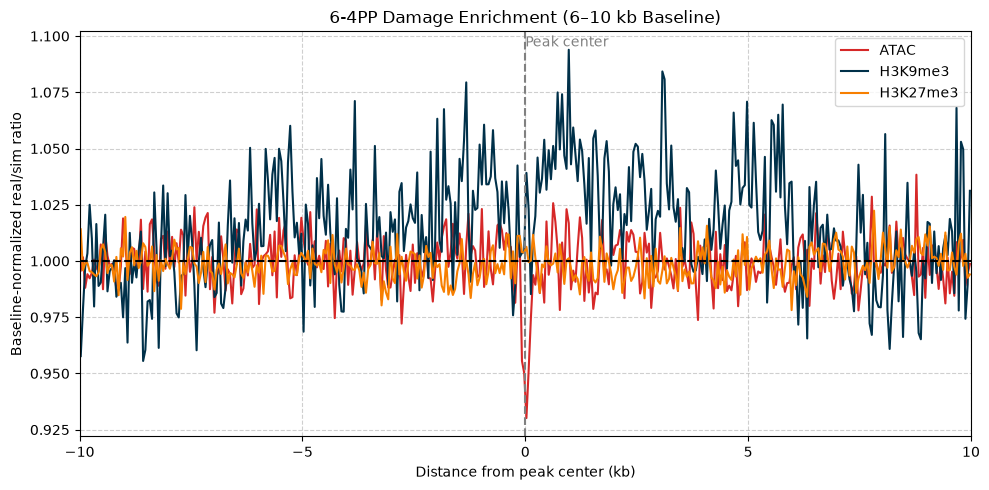

ATAC baseline: 1.1127115740687508
H3K9me3 baseline: 1.0748913364543278
H3K27me3 baseline: 1.051482201233879
Result file: /cta/users/guneyn23/rpkm/rpkm_plots/64 plots/64_baseline_normalized_6_10kb.tsv
Plot file: /cta/users/guneyn23/rpkm/rpkm_plots/64 plots/64_baseline_normalized_6_10kb.png


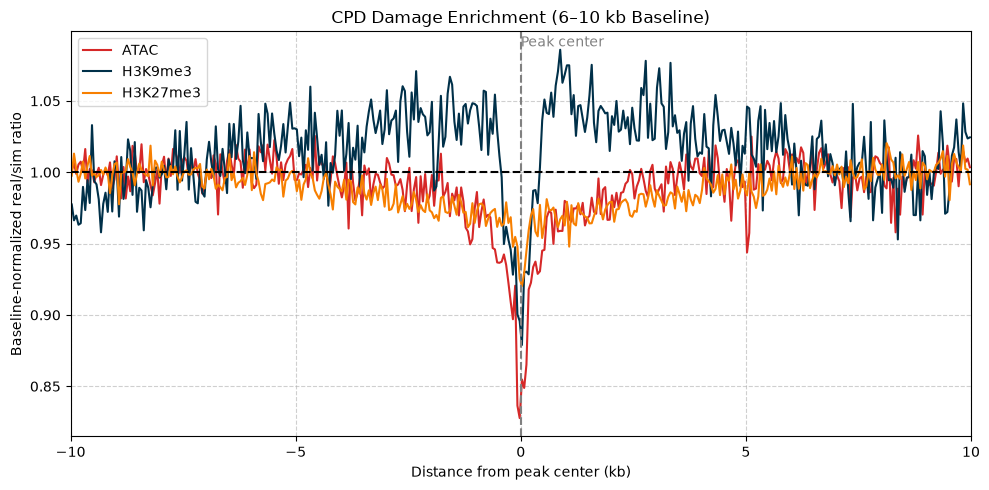

ATAC baseline: 1.0335759512589333
H3K9me3 baseline: 1.0691577732689563
H3K27me3 baseline: 0.9934249431166766
Result file: /cta/users/guneyn23/rpkm/rpkm_plots/CPD plots/CPD_baseline_normalized_6_10kb.tsv
Plot file: /cta/users/guneyn23/rpkm/rpkm_plots/CPD plots/CPD_baseline_normalized_6_10kb.png


In [3]:
number_of_windows = 400

def baseline_normalize(file_path, region_name):
    data = pd.read_csv(file_path, sep='\t')
    values = data['real_sim_ratio'].to_numpy()
    if len(values) != number_of_windows:
        raise ValueError(f'{region_name}: Expected 400 windows, but found {len(values)}.')
    distance_kb = (np.arange(number_of_windows) + 0.5) * 0.05 - 10
    baseline_mask = (((distance_kb >= -10) & (distance_kb <= -6)) | ((distance_kb >= 6) & (distance_kb <= 10)))
    baseline = values[baseline_mask].mean()
    if baseline == 0:
        raise ValueError(f'{region_name}: Baseline is zero, so normalization cannot be performed.')
    normalized = values / baseline
    result = pd.DataFrame({
        'distance_kb': distance_kb, 'real_sim_ratio': values,
        'baseline_normalized_ratio': normalized, 'region': region_name
    })
    return result, baseline

for dataset_name, files in DATASETS.items():
    atac, atac_baseline = baseline_normalize(files['atac_file'], 'ATAC')
    h3k9me3, h3k9me3_baseline = baseline_normalize(files['h3k9me3_file'], 'H3K9me3')
    h3k27me3, h3k27me3_baseline = baseline_normalize(files['h3k27me3_file'], 'H3K27me3')

    result_file = files['output_dir'] / f'{dataset_name}_baseline_normalized_6_10kb.tsv'
    plot_file = files['output_dir'] / f'{dataset_name}_baseline_normalized_6_10kb.png'
    combined = pd.concat([atac, h3k9me3, h3k27me3], ignore_index=True)
    combined.to_csv(result_file, sep='\t', index=False)

    plt.figure(figsize=(10, 5))
    plt.plot(atac['distance_kb'], atac['baseline_normalized_ratio'], color=COLORS['ATAC'], label='ATAC')
    plt.plot(h3k9me3['distance_kb'], h3k9me3['baseline_normalized_ratio'], color=COLORS['H3K9me3'], label='H3K9me3')
    plt.plot(h3k27me3['distance_kb'], h3k27me3['baseline_normalized_ratio'], color=COLORS['H3K27me3'], label='H3K27me3')
    plt.axhline(y=1, color='black', linestyle='--')
    plt.axvline(x=0, color='gray', linestyle='--')
    maximum_value = max(atac['baseline_normalized_ratio'].max(), h3k9me3['baseline_normalized_ratio'].max(), h3k27me3['baseline_normalized_ratio'].max())
    plt.text(0, maximum_value, 'Peak center', color='gray', ha='left', va='bottom')
    plt.xlabel('Distance from peak center (kb)')
    plt.ylabel('Baseline-normalized real/sim ratio')
    plt.title(f"{files['title_name']} Damage Enrichment (6–10 kb Baseline)")
    plt.xlim(-10, 10)
    plt.xticks([-10, -5, 0, 5, 10])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_file, dpi=300)
    plt.show()
    plt.close()

    print('ATAC baseline:', atac_baseline)
    print('H3K9me3 baseline:', h3k9me3_baseline)
    print('H3K27me3 baseline:', h3k27me3_baseline)
    print('Result file:', result_file)
    print('Plot file:', plot_file)

## 3. Simulated RPKM — from `sim_plot_rpkm.py`

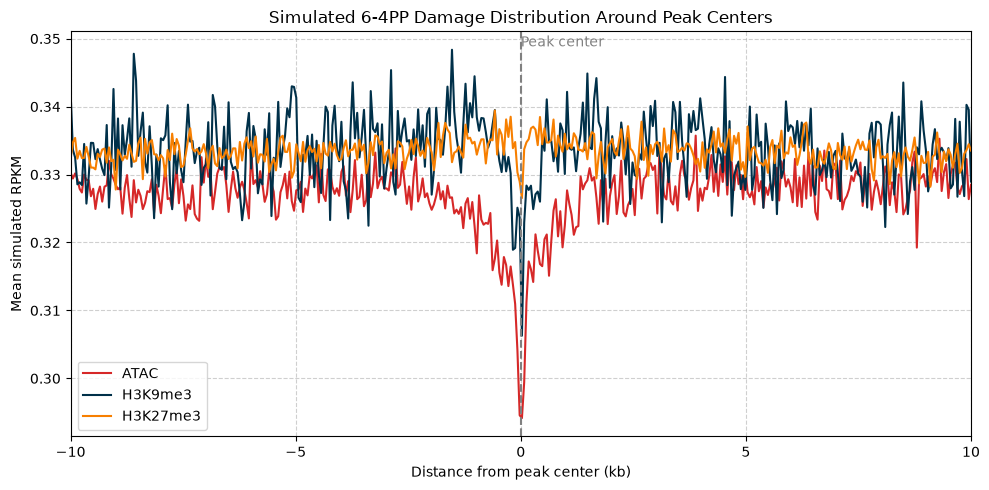

Simulation plot written to: /cta/users/guneyn23/rpkm/rpkm_plots/64 plots/64_simulated_rpkm.png


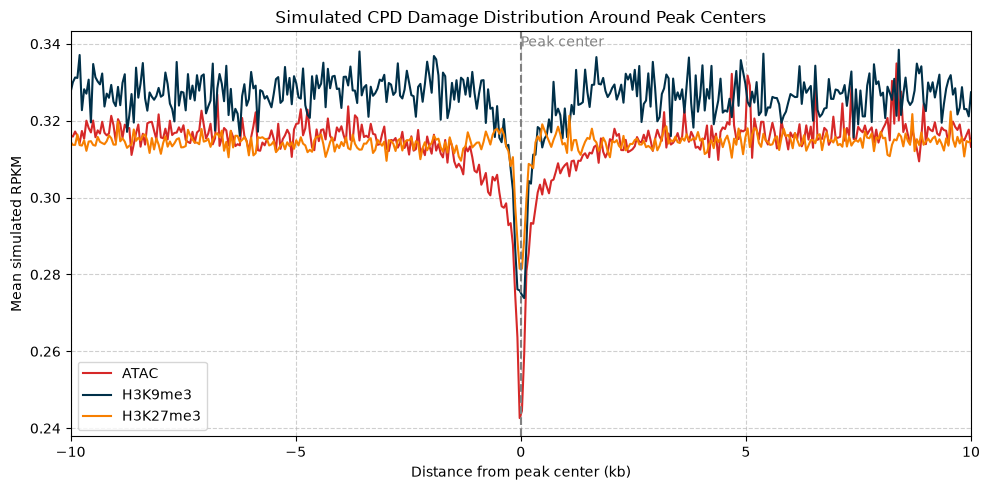

Simulation plot written to: /cta/users/guneyn23/rpkm/rpkm_plots/CPD plots/CPD_simulated_rpkm.png


In [4]:
for dataset_name, files in DATASETS.items():
    atac = pd.read_csv(files['atac_file'], sep='\t')
    h3k9me3 = pd.read_csv(files['h3k9me3_file'], sep='\t')
    h3k27me3 = pd.read_csv(files['h3k27me3_file'], sep='\t')
    x_atac = np.linspace(-10, 10, len(atac))
    x_h3k9me3 = np.linspace(-10, 10, len(h3k9me3))
    x_h3k27me3 = np.linspace(-10, 10, len(h3k27me3))
    plot_file = files['output_dir'] / f'{dataset_name}_simulated_rpkm.png'

    plt.figure(figsize=(10, 5))
    plt.plot(x_atac, atac['mean_sim_rpkm'], color=COLORS['ATAC'], label='ATAC')
    plt.plot(x_h3k9me3, h3k9me3['mean_sim_rpkm'], color=COLORS['H3K9me3'], label='H3K9me3')
    plt.plot(x_h3k27me3, h3k27me3['mean_sim_rpkm'], color=COLORS['H3K27me3'], label='H3K27me3')
    plt.xlabel('Distance from peak center (kb)')
    plt.ylabel('Mean simulated RPKM')
    plt.title(f"Simulated {files['title_name']} Damage Distribution Around Peak Centers")
    plt.axvline(x=0, color='gray', linestyle='--')
    maximum_value = max(atac['mean_sim_rpkm'].max(), h3k9me3['mean_sim_rpkm'].max(), h3k27me3['mean_sim_rpkm'].max())
    plt.text(0, maximum_value, 'Peak center', color='gray', ha='left', va='bottom')
    plt.xlim(-10, 10)
    plt.xticks([-10, -5, 0, 5, 10])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_file, dpi=300)
    plt.show()
    plt.close()
    print(f'Simulation plot written to: {plot_file}')

## 4. Real RPKM — from `real_plot_rpkm.py`

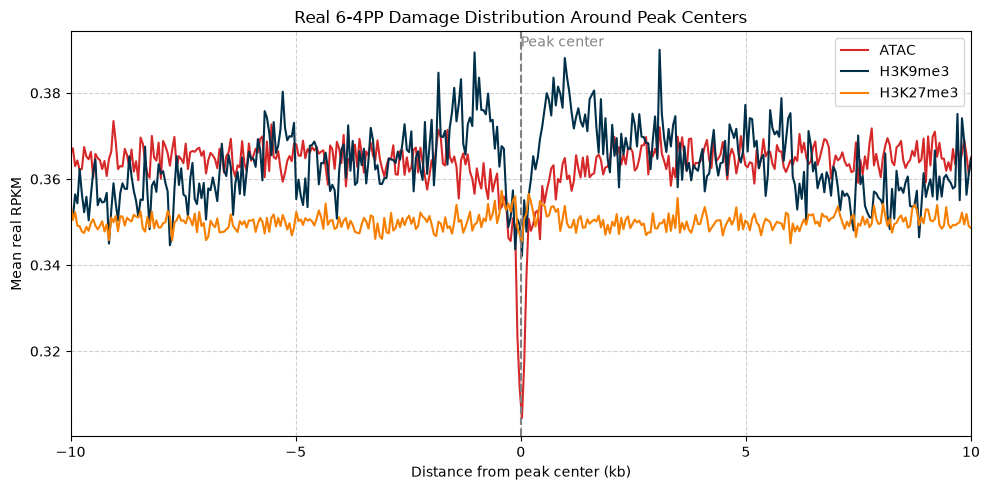

Real plot written to: /cta/users/guneyn23/rpkm/rpkm_plots/64 plots/64_real_rpkm.png


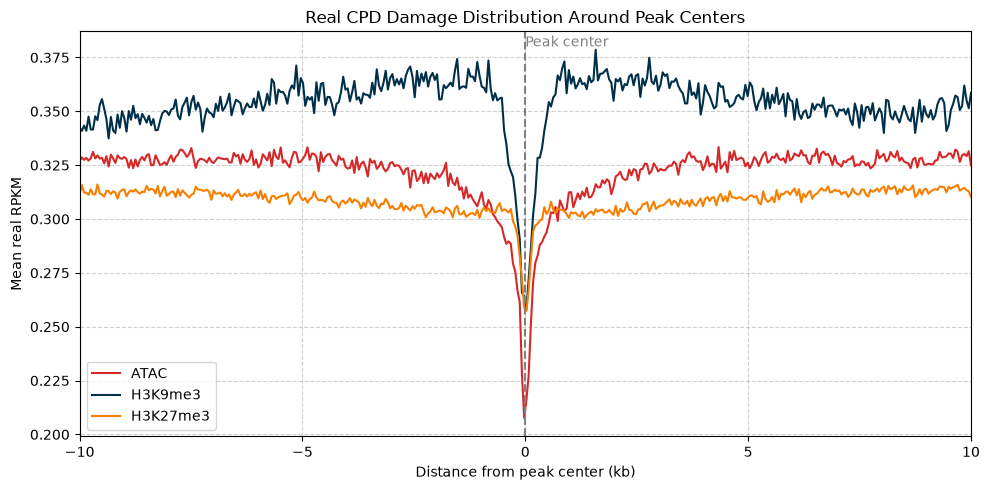

Real plot written to: /cta/users/guneyn23/rpkm/rpkm_plots/CPD plots/CPD_real_rpkm.png


In [5]:
for dataset_name, files in DATASETS.items():
    atac = pd.read_csv(files['atac_file'], sep='\t')
    h3k9me3 = pd.read_csv(files['h3k9me3_file'], sep='\t')
    h3k27me3 = pd.read_csv(files['h3k27me3_file'], sep='\t')
    x_atac = np.linspace(-10, 10, len(atac))
    x_h3k9me3 = np.linspace(-10, 10, len(h3k9me3))
    x_h3k27me3 = np.linspace(-10, 10, len(h3k27me3))
    plot_file = files['output_dir'] / f'{dataset_name}_real_rpkm.png'

    plt.figure(figsize=(10, 5))
    plt.plot(x_atac, atac['mean_real_rpkm'], color=COLORS['ATAC'], label='ATAC')
    plt.plot(x_h3k9me3, h3k9me3['mean_real_rpkm'], color=COLORS['H3K9me3'], label='H3K9me3')
    plt.plot(x_h3k27me3, h3k27me3['mean_real_rpkm'], color=COLORS['H3K27me3'], label='H3K27me3')
    plt.xlabel('Distance from peak center (kb)')
    plt.ylabel('Mean real RPKM')
    plt.title(f"Real {files['title_name']} Damage Distribution Around Peak Centers")
    plt.axvline(x=0, color='gray', linestyle='--')
    maximum_value = max(atac['mean_real_rpkm'].max(), h3k9me3['mean_real_rpkm'].max(), h3k27me3['mean_real_rpkm'].max())
    plt.text(0, maximum_value, 'Peak center', color='gray', ha='left', va='bottom')
    plt.xlim(-10, 10)
    plt.xticks([-10, -5, 0, 5, 10])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_file, dpi=300)
    plt.show()
    plt.close()
    print(f'Real plot written to: {plot_file}')